# Simulate count data for viral variants

In [1]:
import numpy as np
import pandas as pd

from viral_variant_comp.simulate_count_data import create_count_data
from viral_variant_comp.plotting import plot_confidence_intervals_deviation, plot_heatmap, plot_viral_composition_dual
from viral_variant_comp.estimate import calculate_cooccurence
from viral_variant_comp.evaluate import evaluate_result
from viral_variant_comp.estimate import BFGSCompositionEstimator, StepwiseBFGSCompositionEstimator


/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Assume that on average a new variant arises every 2 weeks: $r = 1/14$ with $\lambda = T \cdot r$. 

If for a variant only 0 counts are sampled, the variant is removed.

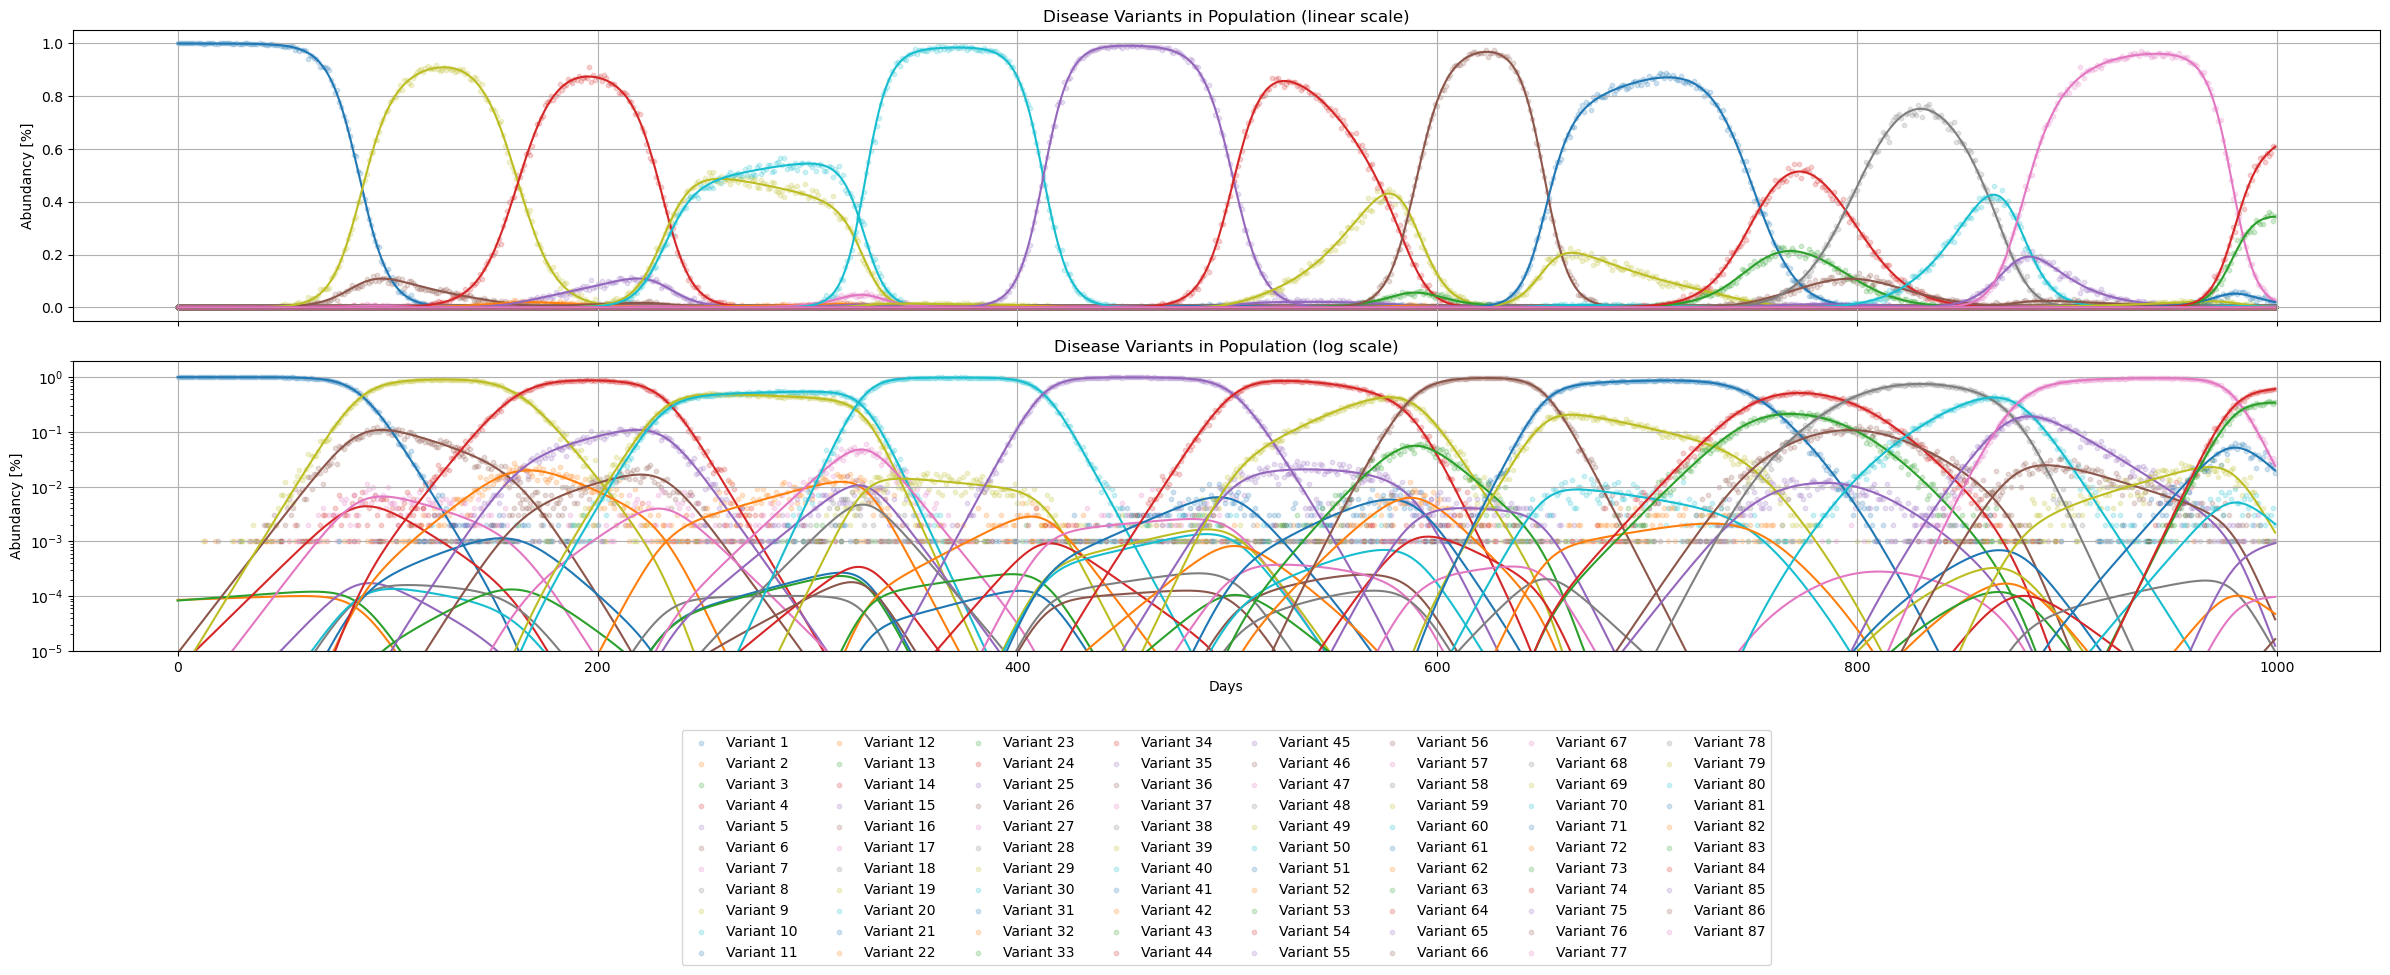

In [6]:
n_variants = 50
n_days = 1000
n_samples = 1000

delta_gr_range = 0.2
s_0 = 0.
o_0 = 0.
rate = 1/14  # per day, on average one new variant every two weeks
freq_entering_variants = 0.0001

data = create_count_data(n_variants = n_variants, n_days = n_days, delta_gr_range = delta_gr_range, new_var_rate = rate, freq_entering_variants = freq_entering_variants, n_samples = n_samples, s_0 = s_0, o_0 = o_0, reorder=True) #data reordered from start
plot_viral_composition_dual(data['counts'], data['freq'], y_range = (1e-5, 2))

#np.savez('data/count_data.npz', **data)
# to reload: np.load('data/count_data.npz')

# Use BFGS (Broyden-Fletcher-Goldfarb-Shanno algorithm) to numerically optimize likelihood function

Likelihood function (multinomial distr.):
$$
\mathcal{L}^{(t)}(s,o) = \mathbb{P}(c^{(t)} \mid p^{(t)}) = \frac{N_t!}{\prod_{i=1}^{n} c_i^{(t)}!} \prod_{i=1}^{n} p_i^{(t)^{c_i^{(t)}}}

$$

Log-Likelihood function (over all t):
$$
\log \mathcal{L}(s,o) = \sum_{t=0}^{T} \left( \sum_{i=1}^{n} c_i^{(t)} \cdot \log p_i(t) \right) + \text{const.} = \sum_{t=0}^{T} \sum_{i=1}^{n} c_i^{(t)} \cdot \left[ s_i t + o_i - \log \left( \sum_{j=1}^{n} e^{s_j t + o_j} \right) \right] + \text{const.}
$$

Derivative:
$$
\frac{\partial \log \mathcal{L}(s, o)}{\partial s_i} =
\sum_{t=0}^{T} c_i^{(t)} \cdot t
- \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t}{\sum_{j=1}^{n} e^{s_j t + o_j}}
$$

$$
\frac{\partial \log \mathcal{L}(s, o)}{\partial o_i} =
\sum_{t=0}^{T} c_i^{(t)} 
- \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i}}{\sum_{j=1}^{n} e^{s_j t + o_j}}
$$

where $N(t) = \sum_{i=0}^{n} c_i^{(t)} $

To avoid not having a clear solution because all parameters are just entering the likelihood as ratios, the growth rate and log. initial frequency of the first variant is fixed to 0.

In [16]:
estimator_bfgs = BFGSCompositionEstimator(data['counts'])
estimator_bfgs.fit()
results_bfgs = estimator_bfgs.get_results()

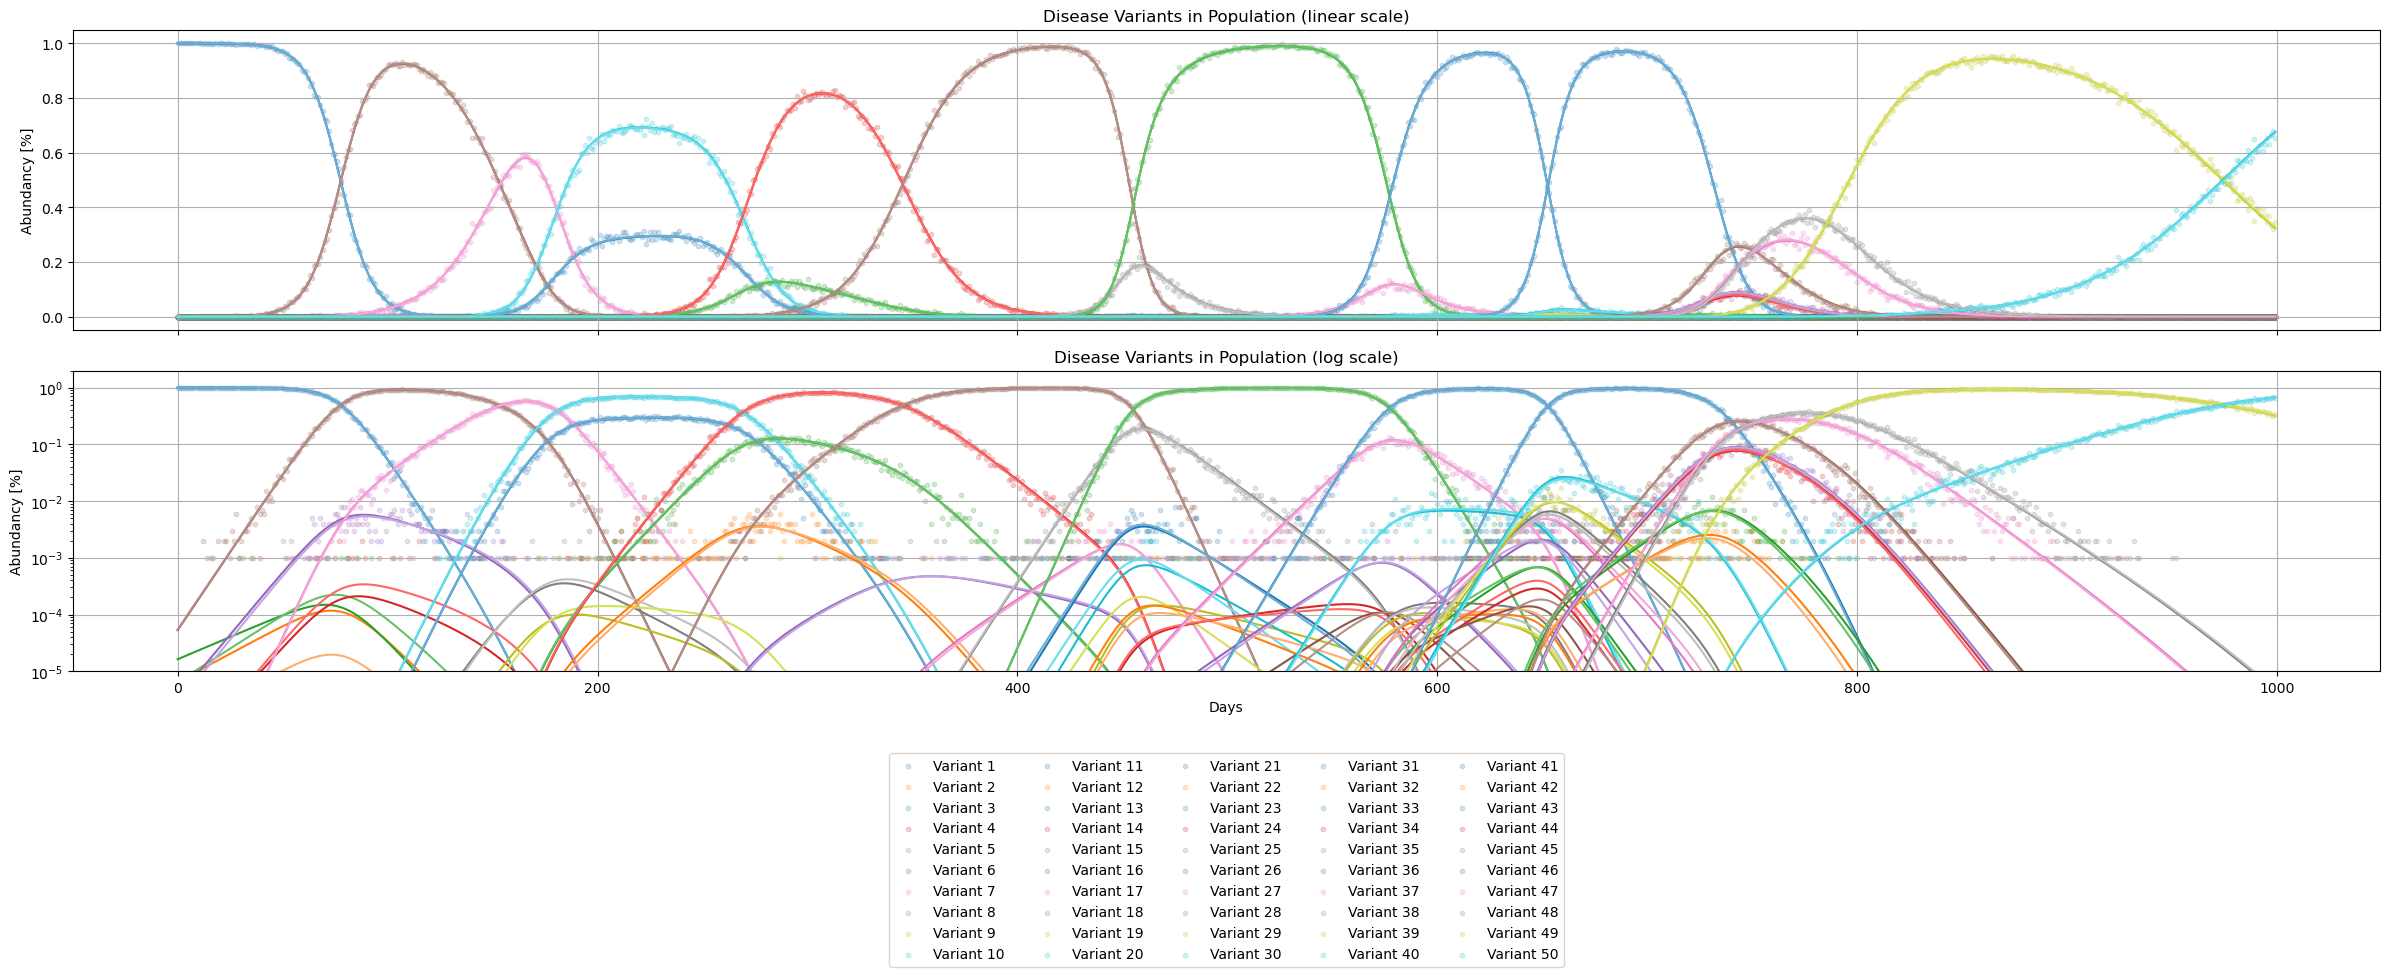

In [17]:
#plot_viral_composition(data['counts'], data['freq'], results_bfgs['composition_estimate'], logscale = False)
#plot_viral_composition(data['counts'], data['freq'], results_bfgs['composition_estimate'], y_range = (1e-5, 2), logscale = True)
plot_viral_composition_dual(data['counts'], data['freq'], results_bfgs['composition_estimate'], y_range = (1e-5, 2))

# Calculate Hessian

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i \partial s_j}
= \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t^2 \cdot e^{s_j t + o_j}}{\left( \sum_{k=1}^{n} e^{s_k t + o_k} \right)^2}
= \sum_{t=0}^{T} N(t) \cdot t^2 \cdot p_i \cdot p_j
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i^2}
= - \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t^2 \left( \sum_{j=1}^{n} e^{s_j t + o_j} - e^{s_i t + o_i} \right)}{\left( \sum_{j=1}^{n} e^{s_j t + o_j} \right)^2}
= - \sum_{t=0}^{T} N(t) \cdot t^2 \cdot p_i \cdot (1 - p_i)
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i \, \partial o_j}
= \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot e^{s_j t + o_j}}{\left( \sum_{k=1}^{n} e^{s_k t + o_k} \right)^2}
= \sum_{t=0}^{T} N(t) \cdot p_i \cdot p_j
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i^2}
= - \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \left( \sum_{j=1}^{n} e^{s_j t + o_j} - e^{s_i t + o_i} \right)}{\left( \sum_{j=1}^{n} e^{s_j t + o_j} \right)^2}
= - \sum_{t=0}^{T} N(t) \cdot p_i \cdot (1 - p_i)
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i \, \partial o_j}
= \frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i \, \partial s_j} 
= \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t \cdot e^{s_j t + o_j}}{\left( \sum_{k=1}^{n} e^{s_k t + o_k} \right)^2}
= \sum_{t=0}^{T} N(t) \cdot t \cdot p_i \cdot p_j
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i \, \partial o_i}
= \frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i \, \partial s_i}
= - \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t \left( \sum_{j=1}^{n} e^{s_j t + o_j} - e^{s_i t + o_i} \right)}{\left( \sum_{j=1}^{n} e^{s_j t + o_j} \right)^2}
= - \sum_{t=0}^{T} N(t) \cdot t \cdot p_i \cdot (1 - p_i)
$$

In [18]:
#counts = data['counts']
#result, composition_estimate = calculate_viral_composition(data['counts'])
#n = counts.shape[1]
#result_hes = calculateHessian(counts, result.x[:n], result.x[n:], ignore_pivot=True)

# Evaluate fit of model

(100,)


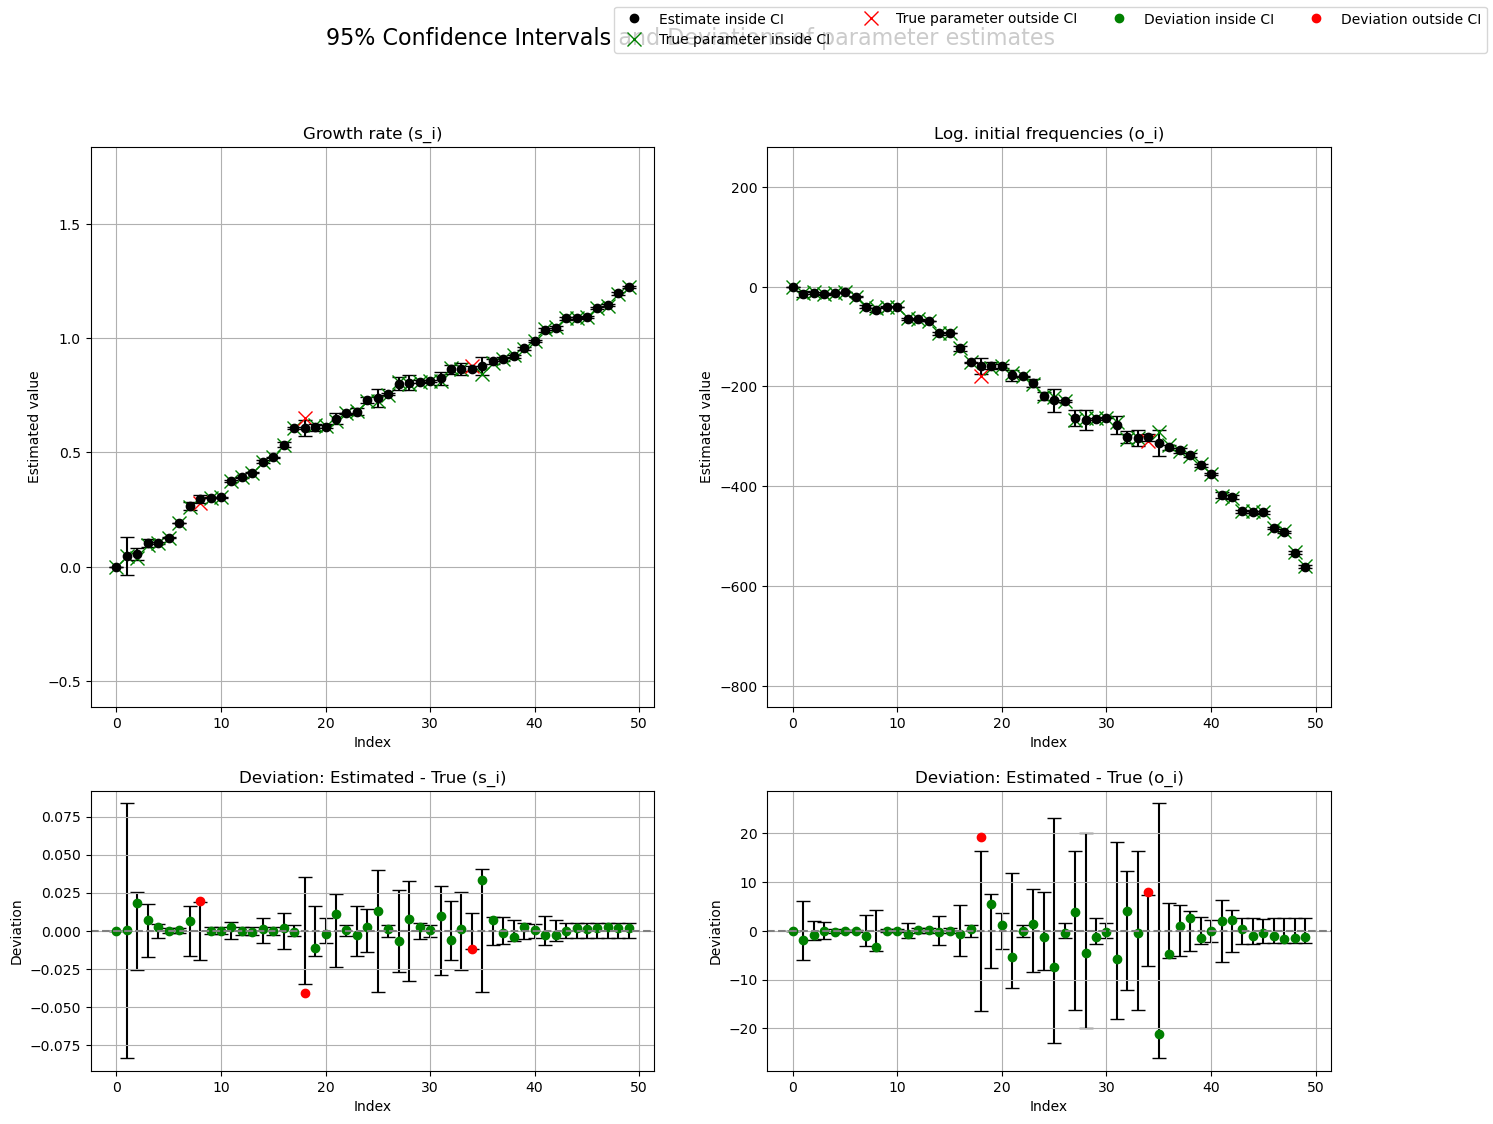

In [19]:
df = evaluate_result(results_bfgs['growth_rate_estimate'], results_bfgs['log_init_freq_estimate'], results_bfgs['hess_inv'], data['growth_rates'], data['log_init_freq'])
plot_confidence_intervals_deviation(df)

# Estimate parameters stepwise

To estimate the parameters more effectively, we can use the fact, that variants, that have been present in the past will not arise again. That's why we can estimate the parameters in a stepwise manner, considering a fixed number of variants at a time.
The variants are ordered according to the timepoint of their peak (average time, weighted by abundance of viral variant). In each estimation step, an overlap size is chosen of variants whose parameter estimates enter the calculation of the next variant. 

Besides in the first window, where the first variant needs to be fixed as a reference, all variant parameters are estimated. If there has been an estimate from the previous window, it is chosen as a new initial parameter. The other variants are initialized with an average over the given initial parameters in the window. The last time, a variant is present in a window, its parameters are saved. To estimate the parameters all variants who arose before the window are included in the calculation of the likelihood but fixed.

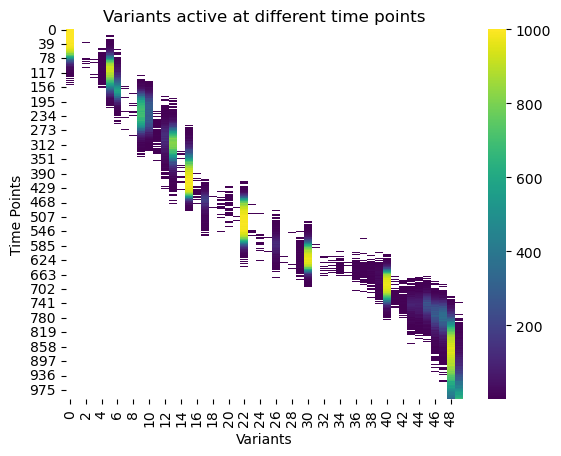

In [20]:
plot_heatmap(data['counts'], "Variants active at different time points", "Variants", "Time Points")

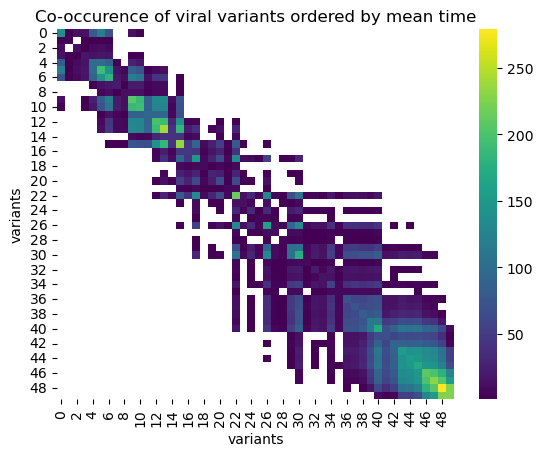

In [21]:
# for reordered data
co_occurence_reorderd = calculate_cooccurence(data['counts'])
plot_heatmap(co_occurence_reorderd, "Co-occurence of viral variants ordered by mean time", "variants", "variants")

In [22]:
data.keys()

dict_keys(['growth_rates', 'log_init_freq', 'freq', 'counts', 'n_variants'])

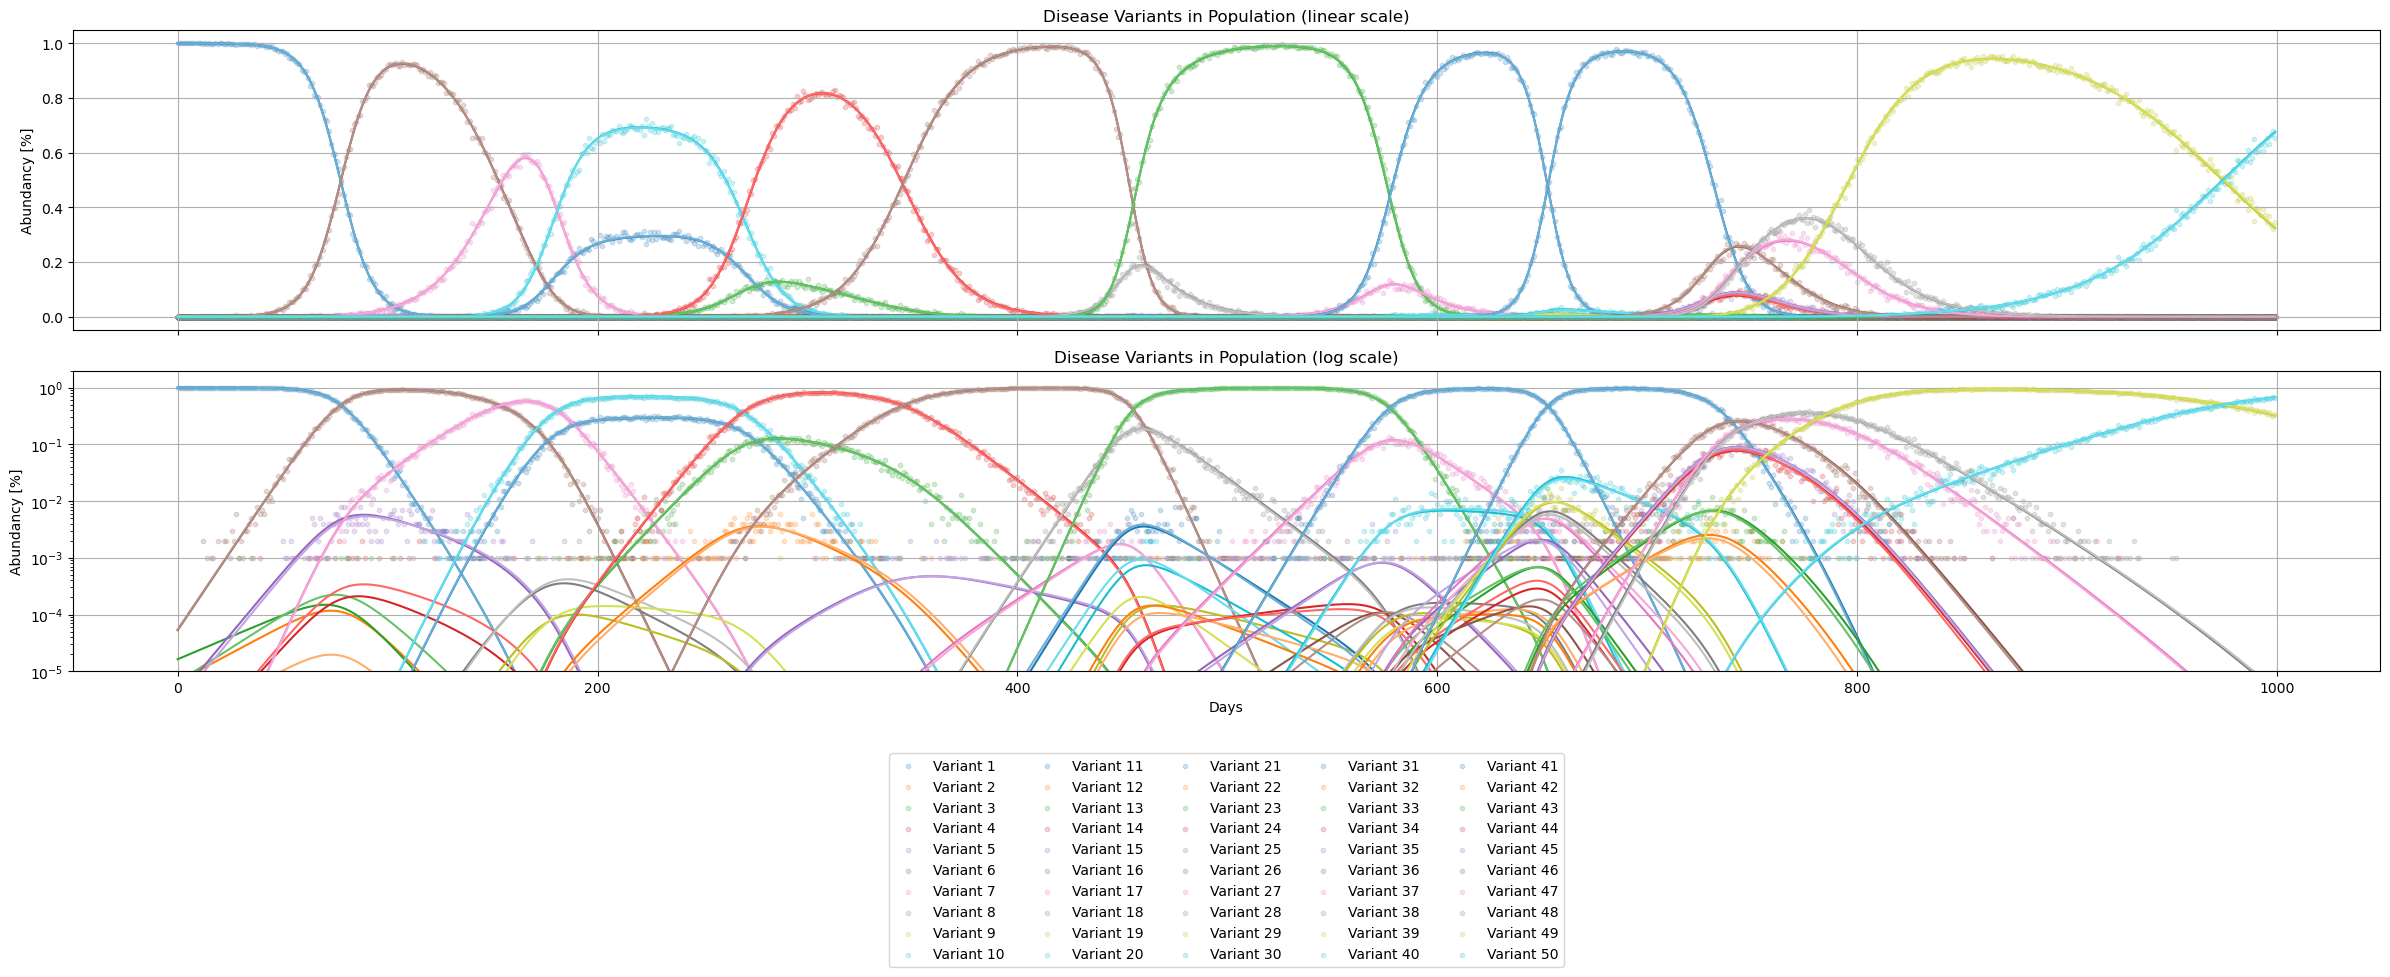

In [23]:
partition_size = 13
overlap_size = 4

estimator_stepwise = StepwiseBFGSCompositionEstimator(data['counts'], partition_size, overlap_size)
estimator_stepwise.fit()
result_stepwise = estimator_stepwise.get_results()

plot_viral_composition_dual(data['counts'], data['freq'], result_stepwise['composition_estimate'], y_range = (1e-5, 2))

(100,)


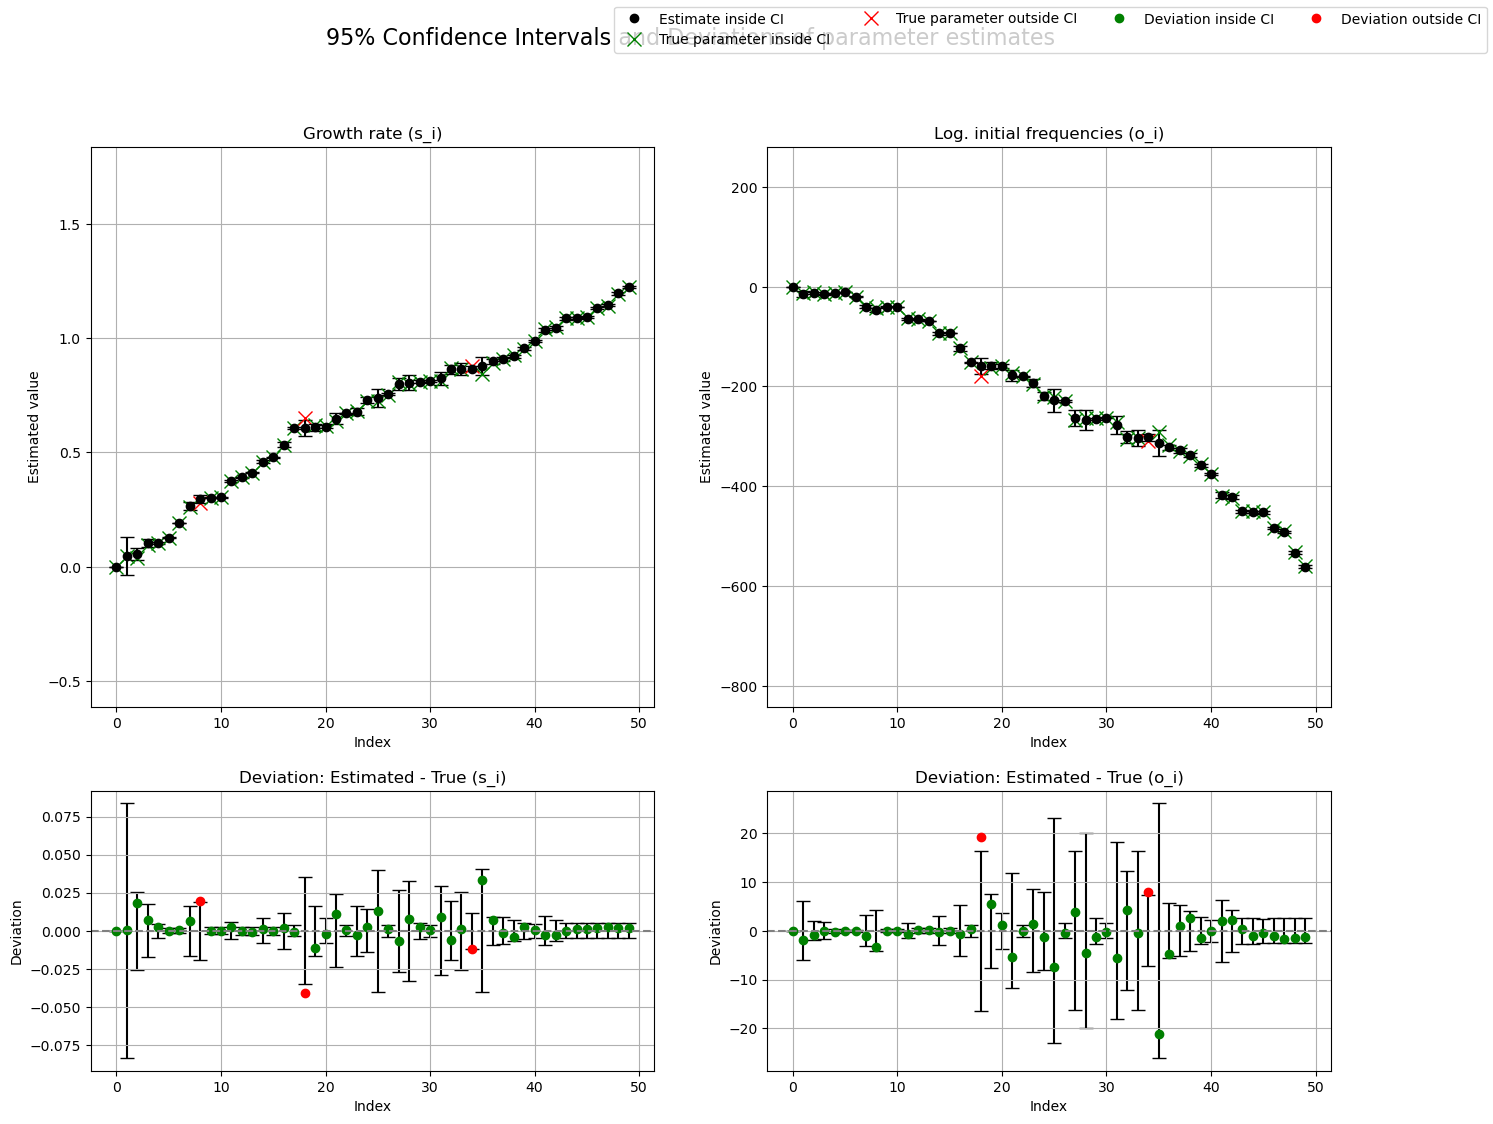

In [24]:
df = evaluate_result(result_stepwise['growth_rate_estimate'], result_stepwise['log_init_freq_estimate'], result_stepwise['hess_inv'], data['growth_rates'], data['log_init_freq'])
plot_confidence_intervals_deviation(df)

In [25]:
df.head()

,parameter_estimate,true_parameter,deviation,abs_deviation,estimated_correctly,standard_error,ci_lower,ci_upper,n_variants,parameter_type
0,0.000000,0.000000,0.000000,0.000000,True,0.000000,0.000000,0.000000,50,growth_rate
1,0.046464,0.045699,0.000765,0.000765,True,0.083579,-0.037115,0.130043,50,growth_rate
2,0.054557,0.036247,0.018311,0.018311,True,0.025685,0.028872,0.080242,50,growth_rate
3,0.102210,0.095273,0.006937,0.006937,True,0.017310,0.084900,0.119520,50,growth_rate
4,0.104295,0.102078,0.002217,0.002217,True,0.004479,0.099816,0.108775,50,growth_rate


A high variance and oftentimes inaccurate parameter estimates are observed when a variant doesn't appear a lot in the data. Usually it only contains 1 count at a few time points.